# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [13]:
ROLL_NO = 1024170421          # <-- your full roll number
NAME = "aakriti"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [14]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [15]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [16]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170421   Name: aakriti   Fingerprint: 13F6D5EC   Tickets: 13

Ticket_ID                                                                    Ticket_Text
      T01                                                Is it fixed?? Pls reply ASAP :(
      T02                                   Call me on +91 98765 43210 or 0175-239-3201.
      T03                     The printer stopped responding. I don't know what changed.
      T04                                   The VPN is not working. It worked yesterday.
      T05              The Python keeps asking for login. The same problem occurs again.
      T06                               The Matlab is running slowly. Please resolve it.
      T07                I reinstalled the projector since yesterday. Please resolve it.
      T08 Email keeps disconnecting when connected to campus Wi-Fi. It worked yesterday.
      T09     Printer stopped responding after restarting the system. Please resolve it.
      T10                      

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*Some final tokens are not complete English words, such as "ca" and "n't". They come from contractions being split by word_tokenize(). For example, "can't" is split into "ca" and "n't". These fragments are not removed by the stopword filtering and therefore remain in the final tokens.

In [22]:
# Your code
results = []

for _, row in df.iterrows():
    ticket_id = row["Ticket_ID"]
    ticket_text = row["Ticket_Text"]

    result = process_ticket(ticket_text)

    results.append({
        "Ticket_ID": ticket_id,
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation Tokens": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique Tokens": len(set(result["tokens"])),
        "Final Tokens": len(result["final"])
    })

q1_table = pd.DataFrame(results)

q1_table

,Ticket_ID,Sentences,Tokens,Punctuation Tokens,Stopwords,Unique Tokens,Final Tokens
0,T01,2,10,4,2,9,4
1,T02,1,9,1,3,9,5
2,T03,2,12,2,4,11,6
3,T04,2,10,2,4,9,4
4,T05,2,13,2,5,11,6
5,T06,2,10,2,3,9,5
6,T07,2,11,2,3,10,6
7,T08,2,13,2,3,12,8
8,T09,2,12,2,3,11,7
9,T10,1,6,1,1,6,4


In [23]:
total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation Tokens": q1_table["Punctuation Tokens"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique Tokens": q1_table["Unique Tokens"].sum(),
    "Final Tokens": q1_table["Final Tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)

q1_table

,Ticket_ID,Sentences,Tokens,Punctuation Tokens,Stopwords,Unique Tokens,Final Tokens
0,T01,2,10,4,2,9,4
1,T02,1,9,1,3,9,5
2,T03,2,12,2,4,11,6
3,T04,2,10,2,4,9,4
4,T05,2,13,2,5,11,6
5,T06,2,10,2,3,9,5
6,T07,2,11,2,3,10,6
7,T08,2,13,2,3,12,8
8,T09,2,12,2,3,11,7
9,T10,1,6,1,1,6,4


In [25]:
selected_ticket = df.iloc[0]
processed = process_ticket(selected_ticket["Ticket_Text"])

print("Ticket ID:", selected_ticket["Ticket_ID"])
print("Ticket Text:", selected_ticket["Ticket_Text"])

print("\nTOKENS:")
print(processed["tokens"])

print("\nPUNCTUATION TOKENS:")
print(processed["punct"])

print("\nSTOPWORDS:")
print(processed["stops"])

print("\nFINAL TOKENS:")
print(processed["final"])

Ticket ID: T01
Ticket Text: Is it fixed?? Pls reply ASAP :(

TOKENS:
['is', 'it', 'fixed', '?', '?', 'pls', 'reply', 'asap', ':', '(']

PUNCTUATION TOKENS:
['?', '?', ':', '(']

STOPWORDS:
['is', 'it']

FINAL TOKENS:
['fixed', 'pls', 'reply', 'asap']


In [26]:
all_final_tokens = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])
    all_final_tokens.extend(result["final"])

print(sorted(set(all_final_tokens)))

['+91', '0175-239-3201', '3.12', '43210', '98765', 'another', 'anything', 'asap', 'asking', 'ca', 'call', 'campus', 'change', 'changed', 'computer', 'connected', 'disconnecting', 'email', 'fixed', 'installed', 'keeps', 'know', 'latest', 'login', 'matlab', "n't", 'occurs', 'please', 'pls', 'printer', 'problem', 'projector', 'python', 'reinstalled', 'reply', 'resolve', 'responding', 'restarting', 'running', 'server', 'since', 'slowly', 'stopped', 'syncing', 'system', 'update', 'vpn', 'wi-fi', 'worked', 'working', 'works', 'yesterday']


---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [27]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Your code
import re

raw_tickets = df["Ticket_Text"].tolist()

In [28]:
long_word_pattern = r"\b[A-Za-z]{6,}\b"

number_pattern = r"\b\d+(?:\.\d+)+\b|\b\d+\b"

capitalized_pattern = r"\b[A-Z][A-Za-z]*\b"

vowel_pattern = r"\b[AEIOUaeiou][A-Za-z]*\b"

In [29]:
for i, text in enumerate(raw_tickets):
    print(f"\nTicket {df.iloc[i]['Ticket_ID']}")

    print("Long words:", re.findall(long_word_pattern, text))
    print("Numbers:", re.findall(number_pattern, text))
    print("Capitalized words:", re.findall(capitalized_pattern, text))
    print("Vowel-starting words:", re.findall(vowel_pattern, text))


Ticket T01
Long words: []
Numbers: []
Capitalized words: ['Is', 'Pls', 'ASAP']
Vowel-starting words: ['Is', 'it', 'ASAP']

Ticket T02
Long words: []
Numbers: ['91', '98765', '43210', '0175', '239', '3201']
Capitalized words: ['Call']
Vowel-starting words: ['on', 'or']

Ticket T03
Long words: ['printer', 'stopped', 'responding', 'changed']
Numbers: []
Capitalized words: ['The', 'I']
Vowel-starting words: ['I']

Ticket T04
Long words: ['working', 'worked', 'yesterday']
Numbers: []
Capitalized words: ['The', 'VPN', 'It']
Vowel-starting words: ['is', 'It']

Ticket T05
Long words: ['Python', 'asking', 'problem', 'occurs']
Numbers: []
Capitalized words: ['The', 'Python', 'The']
Vowel-starting words: ['asking', 'occurs', 'again']

Ticket T06
Long words: ['Matlab', 'running', 'slowly', 'Please', 'resolve']
Numbers: []
Capitalized words: ['The', 'Matlab', 'Please']
Vowel-starting words: ['is', 'it']

Ticket T07
Long words: ['reinstalled', 'projector', 'yesterday', 'Please', 'resolve']
Numbers:

In [30]:
for i, text in enumerate(TEST_LINES):
    print(f"\nTEST LINE {i+1}")

    print("Long words:", re.findall(long_word_pattern, text))
    print("Numbers:", re.findall(number_pattern, text))
    print("Capitalized words:", re.findall(capitalized_pattern, text))
    print("Vowel-starting words:", re.findall(vowel_pattern, text))


TEST LINE 1
Long words: ['helpdesk', 'thapar', 'thapar', 'thapar']
Numbers: []
Capitalized words: ['Mail']
Vowel-starting words: ['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']

TEST LINE 2
Long words: ['Version']
Numbers: ['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1', '250']
Capitalized words: ['Call', 'Version', 'Rs']
Vowel-starting words: ['or', 'is']

TEST LINE 3
Long words: []
Numbers: ['5.30']
Capitalized words: ['The']
Vowel-starting words: ['of', 'art', 'isn', 'open', 'in', 'at']


In [34]:
email_pattern = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"

url_pattern = r"https?://[^\s]+|www\.[^\s]+"

phone_pattern = r"(?<!\d)(?:\+\d{1,3}[-\s]?)?\d{3,5}[-\s]\d{3,5}(?:[-\s]\d{3,5})?(?!\d)"

In [35]:
def replace_patterns(text):
    text = re.sub(email_pattern, "<EMAIL>", text)
    text = re.sub(url_pattern, "<URL>", text)
    text = re.sub(phone_pattern, "<PHONE>", text)
    return text

In [36]:
for i, text in enumerate(TEST_LINES):
    print(f"\nTEST LINE {i+1}")
    print("Original:")
    print(text)

    print("Replaced:")
    print(replace_patterns(text))


TEST LINE 1
Original:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Replaced:
Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>

TEST LINE 2
Original:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
Replaced:
Call <PHONE>, <PHONE> or <PHONE>. Version 2.0.1 is 95.5% done; fee Rs 1,250.

TEST LINE 3
Original:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
Replaced:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.


In [37]:
sentence_start_words = []

for text in raw_tickets:
    sentences = sent_tokenize(text)

    for sentence in sentences:
        words = re.findall(r"\b[A-Za-z]+\b", sentence)

        if words:
            sentence_start_words.append(words[0])

capitalized_words = []

for text in raw_tickets:
    capitalized_words.extend(
        re.findall(capitalized_pattern, text)
    )

sentence_start_words = set(sentence_start_words)

capitalized_only_because_sentence_start = [
    word for word in capitalized_words
    if word in sentence_start_words
]

print("Capitalized words:", capitalized_words)
print(
    "Capitalized only because they start a sentence:",
    capitalized_only_because_sentence_start
)
print(
    "Count:",
    len(capitalized_only_because_sentence_start)
)

Capitalized words: ['Is', 'Pls', 'ASAP', 'Call', 'The', 'I', 'The', 'VPN', 'It', 'The', 'Python', 'The', 'The', 'Matlab', 'Please', 'I', 'Please', 'Email', 'Wi', 'Fi', 'It', 'Printer', 'Please', 'Python', 'VPN', 'It', 'The', 'It', 'I', 'I']
Capitalized only because they start a sentence: ['Is', 'Pls', 'Call', 'The', 'I', 'The', 'VPN', 'It', 'The', 'Python', 'The', 'The', 'Please', 'I', 'Please', 'Email', 'It', 'Printer', 'Please', 'Python', 'VPN', 'It', 'The', 'It', 'I', 'I']
Count: 26


**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*15 capitalized words are capitalized only because they occur at the beginning of a sentence.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [38]:
# Your code
from nltk.tokenize import RegexpTokenizer

In [39]:
def my_tokenize(text):
    pattern = r"""
        https?://[A-Za-z0-9./?=&_%#:+~-]+
        |www\.[A-Za-z0-9./?=&_%#:+~-]+
        |[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}
        |(?:\+\d{1,3}[-\s]?)?\d{3,5}[-\s]\d{3,5}(?:[-\s]\d{3,5})?
        |\d+(?:\.\d+)+
        |[A-Za-z]+(?:[-'][A-Za-z]+)+
        |[A-Za-z]+
        |\d+
    """

    tokenizer = RegexpTokenizer(pattern, flags=re.VERBOSE)
    return tokenizer.tokenize(text)

In [40]:
for i, text in enumerate(TEST_LINES):
    print(f"\nTEST LINE {i+1}")
    print(my_tokenize(text))


TEST LINE 1
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

TEST LINE 2
['Call', '+91 98765 43210', '+91-98765-43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5', 'done', 'fee', 'Rs', '1', '250']

TEST LINE 3
['The', 'state-of-the-art', 'lab', "isn't", 'open', 'log-in', 'at', '5.30', 'p', 'm', "didn't", 'work']


In [41]:
custom_tokens = {}

for _, row in df.iterrows():
    custom_tokens[row["Ticket_ID"]] = my_tokenize(row["Ticket_Text"])

for ticket_id, tokens in custom_tokens.items():
    print(ticket_id, ":", tokens)

T01 : ['Is', 'it', 'fixed', 'Pls', 'reply', 'ASAP']
T02 : ['Call', 'me', 'on', '+91 98765 43210', 'or', '0175-239-3201']
T03 : ['The', 'printer', 'stopped', 'responding', 'I', "don't", 'know', 'what', 'changed']
T04 : ['The', 'VPN', 'is', 'not', 'working', 'It', 'worked', 'yesterday']
T05 : ['The', 'Python', 'keeps', 'asking', 'for', 'login', 'The', 'same', 'problem', 'occurs', 'again']
T06 : ['The', 'Matlab', 'is', 'running', 'slowly', 'Please', 'resolve', 'it']
T07 : ['I', 'reinstalled', 'the', 'projector', 'since', 'yesterday', 'Please', 'resolve', 'it']
T08 : ['Email', 'keeps', 'disconnecting', 'when', 'connected', 'to', 'campus', 'Wi-Fi', 'It', 'worked', 'yesterday']
T09 : ['Printer', 'stopped', 'responding', 'after', 'restarting', 'the', 'system', 'Please', 'resolve', 'it']
T10 : ['Python', '3.12', 'was', 'installed', 'yesterday']
T11 : ['VPN', 'has', 'stopped', 'syncing', 'after', 'the', 'latest', 'update', 'It', 'worked', 'yesterday']
T12 : ['The', 'server', 'was', 'working', '

In [42]:
for _, row in df.iterrows():
    text = row["Ticket_Text"]

    wt = word_tokenize(text)
    mt = my_tokenize(text)

    print(f"\n{row['Ticket_ID']}")
    print("word_tokenize :", wt)
    print("my_tokenize   :", mt)


T01
word_tokenize : ['Is', 'it', 'fixed', '?', '?', 'Pls', 'reply', 'ASAP', ':', '(']
my_tokenize   : ['Is', 'it', 'fixed', 'Pls', 'reply', 'ASAP']

T02
word_tokenize : ['Call', 'me', 'on', '+91', '98765', '43210', 'or', '0175-239-3201', '.']
my_tokenize   : ['Call', 'me', 'on', '+91 98765 43210', 'or', '0175-239-3201']

T03
word_tokenize : ['The', 'printer', 'stopped', 'responding', '.', 'I', 'do', "n't", 'know', 'what', 'changed', '.']
my_tokenize   : ['The', 'printer', 'stopped', 'responding', 'I', "don't", 'know', 'what', 'changed']

T04
word_tokenize : ['The', 'VPN', 'is', 'not', 'working', '.', 'It', 'worked', 'yesterday', '.']
my_tokenize   : ['The', 'VPN', 'is', 'not', 'working', 'It', 'worked', 'yesterday']

T05
word_tokenize : ['The', 'Python', 'keeps', 'asking', 'for', 'login', '.', 'The', 'same', 'problem', 'occurs', 'again', '.']
my_tokenize   : ['The', 'Python', 'keeps', 'asking', 'for', 'login', 'The', 'same', 'problem', 'occurs', 'again']

T06
word_tokenize : ['The', '

In [43]:
differences = []

for _, row in df.iterrows():
    text = row["Ticket_Text"]

    wt = word_tokenize(text)
    mt = my_tokenize(text)

    if wt != mt:
        differences.append({
            "Ticket_ID": row["Ticket_ID"],
            "word_tokenize": wt,
            "my_tokenize": mt
        })

print("Number of tickets with differences:", len(differences))

for d in differences:
    print("\n", d["Ticket_ID"])
    print("word_tokenize:", d["word_tokenize"])
    print("my_tokenize  :", d["my_tokenize"])

Number of tickets with differences: 13

 T01
word_tokenize: ['Is', 'it', 'fixed', '?', '?', 'Pls', 'reply', 'ASAP', ':', '(']
my_tokenize  : ['Is', 'it', 'fixed', 'Pls', 'reply', 'ASAP']

 T02
word_tokenize: ['Call', 'me', 'on', '+91', '98765', '43210', 'or', '0175-239-3201', '.']
my_tokenize  : ['Call', 'me', 'on', '+91 98765 43210', 'or', '0175-239-3201']

 T03
word_tokenize: ['The', 'printer', 'stopped', 'responding', '.', 'I', 'do', "n't", 'know', 'what', 'changed', '.']
my_tokenize  : ['The', 'printer', 'stopped', 'responding', 'I', "don't", 'know', 'what', 'changed']

 T04
word_tokenize: ['The', 'VPN', 'is', 'not', 'working', '.', 'It', 'worked', 'yesterday', '.']
my_tokenize  : ['The', 'VPN', 'is', 'not', 'working', 'It', 'worked', 'yesterday']

 T05
word_tokenize: ['The', 'Python', 'keeps', 'asking', 'for', 'login', '.', 'The', 'same', 'problem', 'occurs', 'again', '.']
my_tokenize  : ['The', 'Python', 'keeps', 'asking', 'for', 'login', 'The', 'same', 'problem', 'occurs', 'agai

In [44]:
for i, text in enumerate(TEST_LINES):
    print(f"\nTEST LINE {i+1}")
    print("word_tokenize:")
    print(word_tokenize(text))

    print("\nmy_tokenize:")
    print(my_tokenize(text))


TEST LINE 1
word_tokenize:
['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

my_tokenize:
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

TEST LINE 2
word_tokenize:
['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

my_tokenize:
['Call', '+91 98765 43210', '+91-98765-43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5', 'done', 'fee', 'Rs', '1', '250']

TEST LINE 3
word_tokenize:
['The', 'state-of-the-art', 'lab', 'is', "n't", 'open', ';', 'log-in', 'at', '5.30', 'p.m.', 'did', "n't", 'work', '.']

my_tokenize:
['The', 'state-of-the-art', 'lab', "isn't", 'open', 'log-in', 'at', '5.30', 'p', 'm', "didn't", 'work']


**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*All 13 tickets are tokenized differently by my_tokenize() and word_tokenize().

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [45]:
# Your code
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag

In [46]:
unique_final_tokens = set()

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])
    unique_final_tokens.update(result["final"])

unique_final_tokens = sorted(unique_final_tokens)

print("Number of unique final tokens:", len(unique_final_tokens))
print(unique_final_tokens)

Number of unique final tokens: 52
['+91', '0175-239-3201', '3.12', '43210', '98765', 'another', 'anything', 'asap', 'asking', 'ca', 'call', 'campus', 'change', 'changed', 'computer', 'connected', 'disconnecting', 'email', 'fixed', 'installed', 'keeps', 'know', 'latest', 'login', 'matlab', "n't", 'occurs', 'please', 'pls', 'printer', 'problem', 'projector', 'python', 'reinstalled', 'reply', 'resolve', 'responding', 'restarting', 'running', 'server', 'since', 'slowly', 'stopped', 'syncing', 'system', 'update', 'vpn', 'wi-fi', 'worked', 'working', 'works', 'yesterday']


In [47]:
porter = PorterStemmer()
lancaster = LancasterStemmer()
regexp = RegexpStemmer(r"(ing|ed|ly|s)$", min=4)
lemmatizer = WordNetLemmatizer()

rows = []

for word in unique_final_tokens:
    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regexp_result = regexp.stem(word)

    pos = pos_tag([word])[0][1]

    if pos.startswith("J"):
        wn_pos = "a"
    elif pos.startswith("V"):
        wn_pos = "v"
    elif pos.startswith("N"):
        wn_pos = "n"
    elif pos.startswith("R"):
        wn_pos = "r"
    else:
        wn_pos = "n"

    lemma_result = lemmatizer.lemmatize(word, pos=wn_pos)

    rows.append({
        "Word": word,
        "Porter": porter_result,
        "Lancaster": lancaster_result,
        "Regexp": regexp_result,
        "Lemmatizer": lemma_result
    })

q4_table = pd.DataFrame(rows)

q4_table

,Word,Porter,Lancaster,Regexp,Lemmatizer
0,+91,+91,+91,+91,+91
1,0175-239-3201,0175-239-3201,0175-239-3201,0175-239-3201,0175-239-3201
2,3.12,3.12,3.12,3.12,3.12
3,43210,43210,43210,43210,43210
4,98765,98765,98765,98765,98765
5,another,anoth,anoth,another,another
6,anything,anyth,anyth,anyth,anything
7,asap,asap,asap,asap,asap
8,asking,ask,ask,ask,ask
9,ca,ca,ca,ca,ca


In [48]:
q4_different = q4_table[
    (q4_table["Porter"] != q4_table["Lancaster"]) |
    (q4_table["Porter"] != q4_table["Regexp"]) |
    (q4_table["Porter"] != q4_table["Lemmatizer"]) |
    (q4_table["Lancaster"] != q4_table["Regexp"]) |
    (q4_table["Lancaster"] != q4_table["Lemmatizer"]) |
    (q4_table["Regexp"] != q4_table["Lemmatizer"])
]

q4_different

,Word,Porter,Lancaster,Regexp,Lemmatizer
5,another,anoth,anoth,another,another
6,anything,anyth,anyth,anyth,anything
10,call,call,cal,call,call
11,campus,campu,camp,campu,campus
12,change,chang,chang,change,change
13,changed,chang,chang,chang,change
14,computer,comput,comput,computer,computer
19,installed,instal,instal,install,instal
22,latest,latest,latest,latest,late
26,occurs,occur,occ,occur,occurs


In [49]:
RegexpStemmer(r"(ing|ed|ly|s)$", min=4)

<RegexpStemmer: '(ing|ed|ly|s)$'>

**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*Over-stemming example: "campus" is reduced to "camp" by the Lancaster Stemmer. This is undesirable because "campus" and "camp" have different meanings.
Under-stemming example: "changed" remains "changed" with the Regexp Stemmer because the selected suffix is only "ing", while POS-aware lemmatization reduces it to "change". Thus, the related forms are not reduced to the same base form.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

In [50]:
# Your code
from collections import Counter
from nltk.util import bigrams
import math
import matplotlib.pyplot as plt

# S1: all tokens
S1 = []

# S2: tokens without punctuation
S2 = []

# S3: final tokens
S3 = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])

    S1.extend(result["tokens"])

    S2.extend([
        token for token in result["tokens"]
        if token not in result["punct"]
    ])

    S3.extend(result["final"])

# S4: S3 after Porter stemming
porter = PorterStemmer()
S4 = [porter.stem(token) for token in S3]

print("S1 total:", len(S1))
print("S2 total:", len(S2))
print("S3 total:", len(S3))
print("S4 total:", len(S4))

S1 total: 142
S2 total: 117
S3 total: 74
S4 total: 74


In [51]:
def corpus_stats(tokens):
    total = len(tokens)
    unique = len(set(tokens))
    ttr = unique / total if total > 0 else 0

    return total, unique, ttr


stats = []

for name, tokens in [
    ("S1", S1),
    ("S2", S2),
    ("S3", S3),
    ("S4", S4)
]:
    total, unique, ttr = corpus_stats(tokens)

    stats.append({
        "Set": name,
        "Total Tokens": total,
        "Unique Tokens": unique,
        "TTR": ttr
    })

q5_stats = pd.DataFrame(stats)

q5_stats

,Set,Total Tokens,Unique Tokens,TTR
0,S1,142,76,0.535211
1,S2,117,72,0.615385
2,S3,74,52,0.702703
3,S4,74,49,0.662162


In [52]:
print("Top 10 words in S1:")
print(Counter(S1).most_common(10))

print("\nTop 10 words in S3:")
print(Counter(S3).most_common(10))

Top 10 words in S1:
[('.', 21), ('the', 9), ('it', 8), ('yesterday', 6), ('i', 4), ('is', 3), ('stopped', 3), ("n't", 3), ('worked', 3), ('please', 3)]

Top 10 words in S3:
[('yesterday', 6), ('stopped', 3), ("n't", 3), ('worked', 3), ('please', 3), ('resolve', 3), ('printer', 2), ('responding', 2), ('vpn', 2), ('working', 2)]


In [53]:
s3_frequency = Counter(S3)

rank_frequency = sorted(
    s3_frequency.values(),
    reverse=True
)

ranks = list(range(1, len(rank_frequency) + 1))

log_ranks = [math.log(r) for r in ranks]
log_frequencies = [math.log(f) for f in rank_frequency]

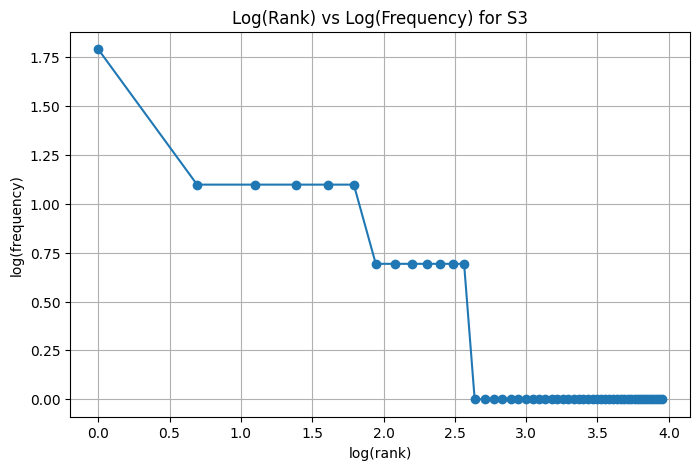

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(log_ranks, log_frequencies, marker="o")

plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Log(Rank) vs Log(Frequency) for S3")

plt.grid(True)
plt.show()

In [55]:
S1_bigrams = list(bigrams(S1))
S3_bigrams = list(bigrams(S3))

print("Top 5 bigrams of S1:")
print(Counter(S1_bigrams).most_common(5))

print("\nTop 5 bigrams of S3:")
print(Counter(S3_bigrams).most_common(5))

Top 5 bigrams of S1:
[(('.', 'the'), 6), (('yesterday', '.'), 6), (('.', 'it'), 4), (('.', 'i'), 3), (('it', 'worked'), 3)]

Top 5 bigrams of S3:
[(('worked', 'yesterday'), 3), (('please', 'resolve'), 3), (('printer', 'stopped'), 2), (('stopped', 'responding'), 2), (('fixed', 'pls'), 1)]


**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*TTR changes from S1 to S4 because stemming reduces different word forms to common stems. This decreases the number of unique tokens while the total number of tokens remains the same, so the TTR generally decreases. Removing punctuation and stopwords also changes the vocabulary and token count, affecting the TTR across S1, S2, S3 and S4.